In [1]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("electronics_products_pricing.csv")

print("Kích thước dữ liệu:", df.shape)
df.head()

Kích thước dữ liệu: (5436, 25)


,id,prices.availability,prices.condition,prices.currency,prices.dateSeen,prices.isSale,prices.merchant,prices.shipping,prices.sourceURLs,asins,...,imageURLs,keys,manufacturer,manufacturerNumber,name,primaryCategories,sourceURLs,upc,weight,price
0,AVphrugr1cnluZ0-FOeH,Yes,New,USD,"2017-05-10T20:00:00Z,2017-05-09T15:00:00Z",False,Bestbuy.com,NaN,http://www.bestbuy.com/site/products/7100293.p...,B00I9HD8PK,...,https://i5.walmartimages.com/asr/dd5f42c4-076c...,"819127010485,ecoxgearecostonebluetoothspeaker/...",Ecoxgear,GDI-EGST701,EcoXGear Ecostone Bluetooth Speaker,Electronics,http://www.walmart.com/ip/EcoXGear-Ecostone-Bl...,8.19E+11,3 pounds,92.99
1,AVrI6FDbv8e3D1O-lm4R,Yes,New,USD,"2017-10-10T02:00:00Z,2017-08-12T03:00:00Z,2017...",False,Bestbuy.com,NaN,https://www.bestbuy.com/site/lenovo-100s-14ibr...,B06ZY63J8H,...,https://i5.walmartimages.com/asr/fcc50cce-a3c1...,"190793918948,lenovo100s14ibr14laptopintelceler...",NaN,100s-14ibr,Lenovo - 100S-14IBR 14 Laptop - Intel Celeron ...,Electronics,https://www.walmart.com/ip/Lenovo-100S-14IBR-1...,1.91E+11,4.3 pounds,229.99
2,AVpiLlubilAPnD_xBoTa,Yes,New,USD,"2017-10-10T19:00:00Z,2017-09-12T14:00:00Z,2017...",False,Bestbuy.com,NaN,https://www.bestbuy.com/site/house-of-marley-s...,B00G3P9UMU,...,https://i5.walmartimages.com/asr/c124aa15-b9e3...,"0846885007037,houseofmarleysmilejamaicainearea...",House Of Marley,EM-JE041-MI,House of Marley Smile Jamaica In-Ear Earbuds,Electronics,https://www.walmart.com/ip/House-of-Marley-Smi...,8.47E+11,0.6 ounces,16.99
3,AVpgQP5vLJeJML43LQbd,Yes,New,USD,"2017-09-08T05:00:00Z,2017-09-18T13:00:00Z,2017...",False,Bestbuy.com,NaN,https://www.bestbuy.com/site/products/6311012....,B00TTWZFFA,...,https://i5.walmartimages.com/asr/1be435f7-5f3a...,"sonyultraportablebluetoothspeaker/sosrsx11bk,s...",Sony,SRSX11/BLK,Sony Ultra-Portable Bluetooth Speaker,Electronics,https://www.walmart.com/ip/Sony-Ultra-Portable...,27242886599,1 pounds,69.99
4,AV1YDsmoGV-KLJ3adcbe,More on the Way,New,USD,2017-12-05T13:00:00Z,True,bhphotovideo.com,Free Expedited Shipping for most orders over $49,https://www.bhphotovideo.com/c/product/1105014...,B00MHPAF38,...,http://i.ebayimg.com/thumbs/images/g/TBUAAOSwd...,sonyalphaa5100digitalcamerakitwith1650mmlenswh...,NaN,ILCE5100L/W,Alpha a5100 Mirrorless Digital Camera with 16-...,Electronics,https://reviews.bestbuy.com/3545/8429343/revie...,27242883246,9.98 oz 4.09 oz,846.00


In [3]:
print("Số dòng:", len(df))
print("Số cột:", len(df.columns))

print("\nSố giá trị thiếu:")
print(df.isnull().sum())

print("\nSố dòng trùng:", df.duplicated().sum())

Số dòng: 5436
Số cột: 25

Số giá trị thiếu:
id                        0
prices.availability       0
prices.condition          0
prices.currency           0
prices.dateSeen           0
prices.isSale             0
prices.merchant           0
prices.shipping        2237
prices.sourceURLs         0
asins                     0
brand                     0
categories                0
dateAdded                 0
dateUpdated               0
ean                    4261
imageURLs                 0
keys                      0
manufacturer           2959
manufacturerNumber        0
name                      0
primaryCategories         0
sourceURLs                0
upc                       0
weight                    0
price                     0
dtype: int64

Số dòng trùng: 0


In [4]:
def convert_weight_to_kg(value):
    if pd.isna(value):
        return np.nan

    value = str(value).lower().strip()

    match = re.search(r'([\d.]+)\s*(pounds?|lbs?|lb|ounces?|oz|kg)', value)

    if match is None:
        return np.nan

    number = float(match.group(1))
    unit = match.group(2)

    if unit == "kg":
        return number
    elif unit in ["pound", "pounds", "lb", "lbs"]:
        return number * 0.453592
    elif unit in ["ounce", "ounces", "oz"]:
        return number * 0.0283495

    return np.nan


df["weight_kg"] = df["weight"].apply(convert_weight_to_kg)

print(df[["weight", "weight_kg"]].head(10))

            weight  weight_kg
0         3 pounds   1.360776
1       4.3 pounds   1.950446
2       0.6 ounces   0.017010
3         1 pounds   0.453592
4  9.98 oz 4.09 oz   0.282928
5             15.6        NaN
6      54.5 pounds  24.720764
7      18.3 pounds   8.300734
8           3.2 Kg   3.200000
9  9.98 oz 4.09 oz   0.282928


In [5]:
model_df = df[["weight_kg", "price"]].dropna()

x = model_df[["weight_kg"]]
y = model_df["price"]

print("Số dòng sau khi xử lý:", len(model_df))

Số dòng sau khi xử lý: 5370


In [6]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", len(x_train))
print("Testing set:", len(x_test))

Training set: 4296
Testing set: 1074


In [7]:
linear_model = LinearRegression()

linear_model.fit(x_train, y_train)

y_pred_linear = linear_model.predict(x_test)

print("10 giá dự đoán đầu tiên:")
print(y_pred_linear[:10])

10 giá dự đoán đầu tiên:
[ 361.70193771  282.1211074   410.33466734  363.91251633  324.12210117
  260.23637906  279.49604529 1922.37044324  302.67948856  263.88383378]


In [8]:
tree_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

tree_model.fit(x_train, y_train)

y_pred_tree = tree_model.predict(x_test)

print("10 giá dự đoán đầu tiên:")
print(y_pred_tree[:10])

10 giá dự đoán đầu tiên:
[ 513.63910007  295.22533276  513.63910007  513.63910007  121.06115385
  101.72142857  295.22533276 2039.3314876   295.22533276  101.72142857]


In [9]:
forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_model.fit(x_train, y_train)

y_pred_forest = forest_model.predict(x_test)

print("10 giá dự đoán đầu tiên:")
print(y_pred_forest[:10])

10 giá dự đoán đầu tiên:
[ 121.9857104   162.74189384  192.38817932   67.3272764   141.56120971
   73.01097026   72.37371734 2960.57205253  139.75110904  110.36314575]


In [10]:
models = {
    "Linear Regression": y_pred_linear,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_forest
}

results = []

for name, prediction in models.items():
    mae = mean_absolute_error(y_test, prediction)
    mse = mean_squared_error(y_test, prediction)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, prediction)

    results.append([
        name,
        mae,
        mse,
        rmse,
        r2
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2"]
)

results_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,384.291044,402822.682501,634.683136,0.401139
1,Decision Tree,324.408622,289038.761394,537.623252,0.570297
2,Random Forest,178.336304,137401.297489,370.676810,0.795731


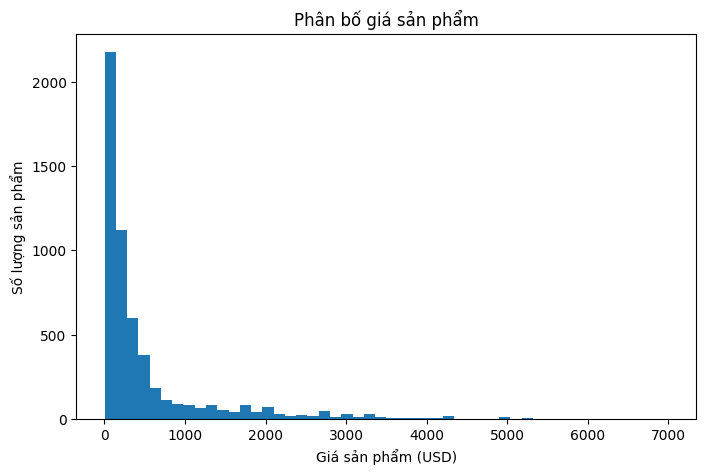

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(df["price"].dropna(), bins=50)

plt.xlabel("Giá sản phẩm (USD)")
plt.ylabel("Số lượng sản phẩm")
plt.title("Phân bố giá sản phẩm")

plt.show()

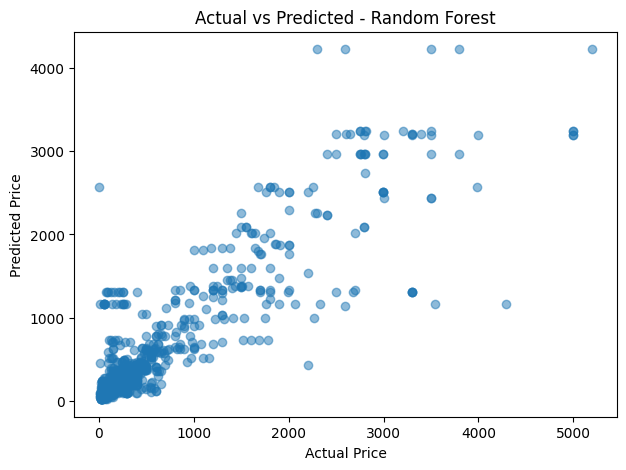

In [11]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred_forest, alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted - Random Forest")

plt.show()

In [15]:
weight_input = 5

predicted_price = forest_model.predict(
    pd.DataFrame({"weight_kg": [weight_input]})
)

print(
    f"Với sản phẩm có trọng lượng {weight_input} kg,"
    f" giá dự đoán là: ${predicted_price[0]:.2f}"
)

Với sản phẩm có trọng lượng 5 kg, giá dự đoán là: $194.35


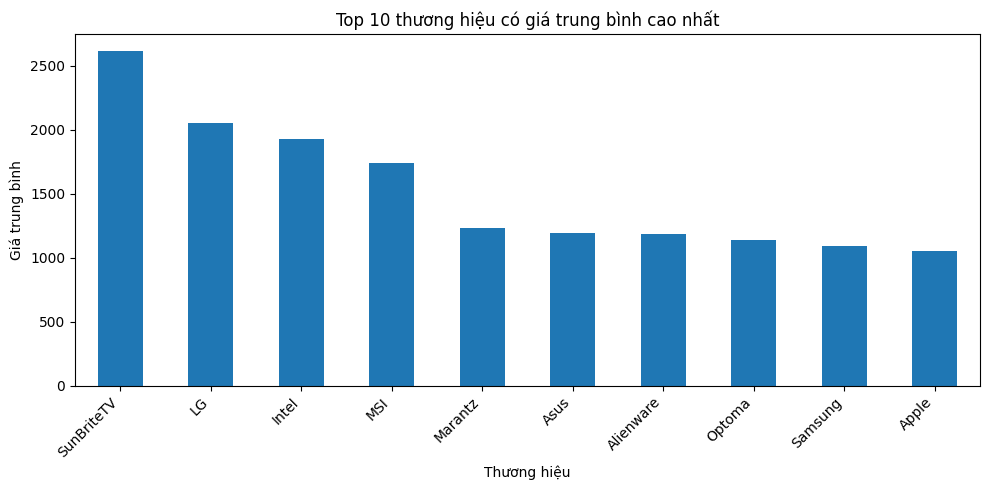

In [18]:
avg_price = df.groupby('brand')['price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
avg_price.plot(kind='bar')

plt.title('Top 10 thương hiệu có giá trung bình cao nhất')
plt.xlabel('Thương hiệu')
plt.ylabel('Giá trung bình')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

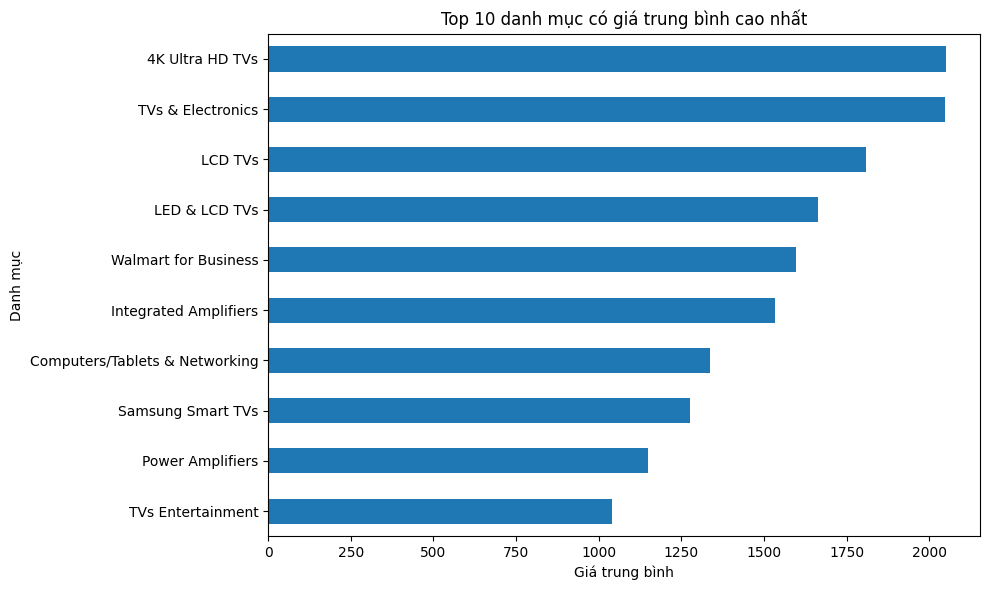

In [19]:
df['category'] = df['categories'].str.split(',').str[0]

avg_price = df.groupby('category')['price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
avg_price.sort_values().plot(kind='barh')

plt.title('Top 10 danh mục có giá trung bình cao nhất')
plt.xlabel('Giá trung bình')
plt.ylabel('Danh mục')
plt.tight_layout()
plt.show()